# Solvers and Jacobians

For a transition $f$, the equilibrium solves

$$
r(z)=f(z)-z=0.
$$

Local stability is governed by the state Jacobian

$$
J_z=\frac{\partial f}{\partial z}(z^\star).
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[10]](https://jseluis.github.io/silva-networks/paper/references/#ref-10), [[11]](https://jseluis.github.io/silva-networks/paper/references/#ref-11), [[12]](https://jseluis.github.io/silva-networks/paper/references/#ref-12), [[13]](https://jseluis.github.io/silva-networks/paper/references/#ref-13), [[14]](https://jseluis.github.io/silva-networks/paper/references/#ref-14). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
from silva_networks import SolverConfig, fixed_point, full_jacobian, jvp, stability_report, vjp

torch.manual_seed(1)
W = 0.25 * torch.randn(4, 4)
b = torch.linspace(-0.2, 0.2, 4)

def f(z):
    return torch.tanh(W @ z + b)

z0 = torch.zeros(4)

In [3]:
solver_runs = {}
for solver in ["picard", "anderson", "broyden"]:
    result = fixed_point(f, z0, SolverConfig(solver=solver, max_iter=20, alpha=0.6))
    solver_runs[solver] = result
    print(solver, result.iterations, result.residual)

picard 17 7.477725603166618e-07
anderson 20 7.905589882284403e-05
broyden 15 4.4529298293127795e-07


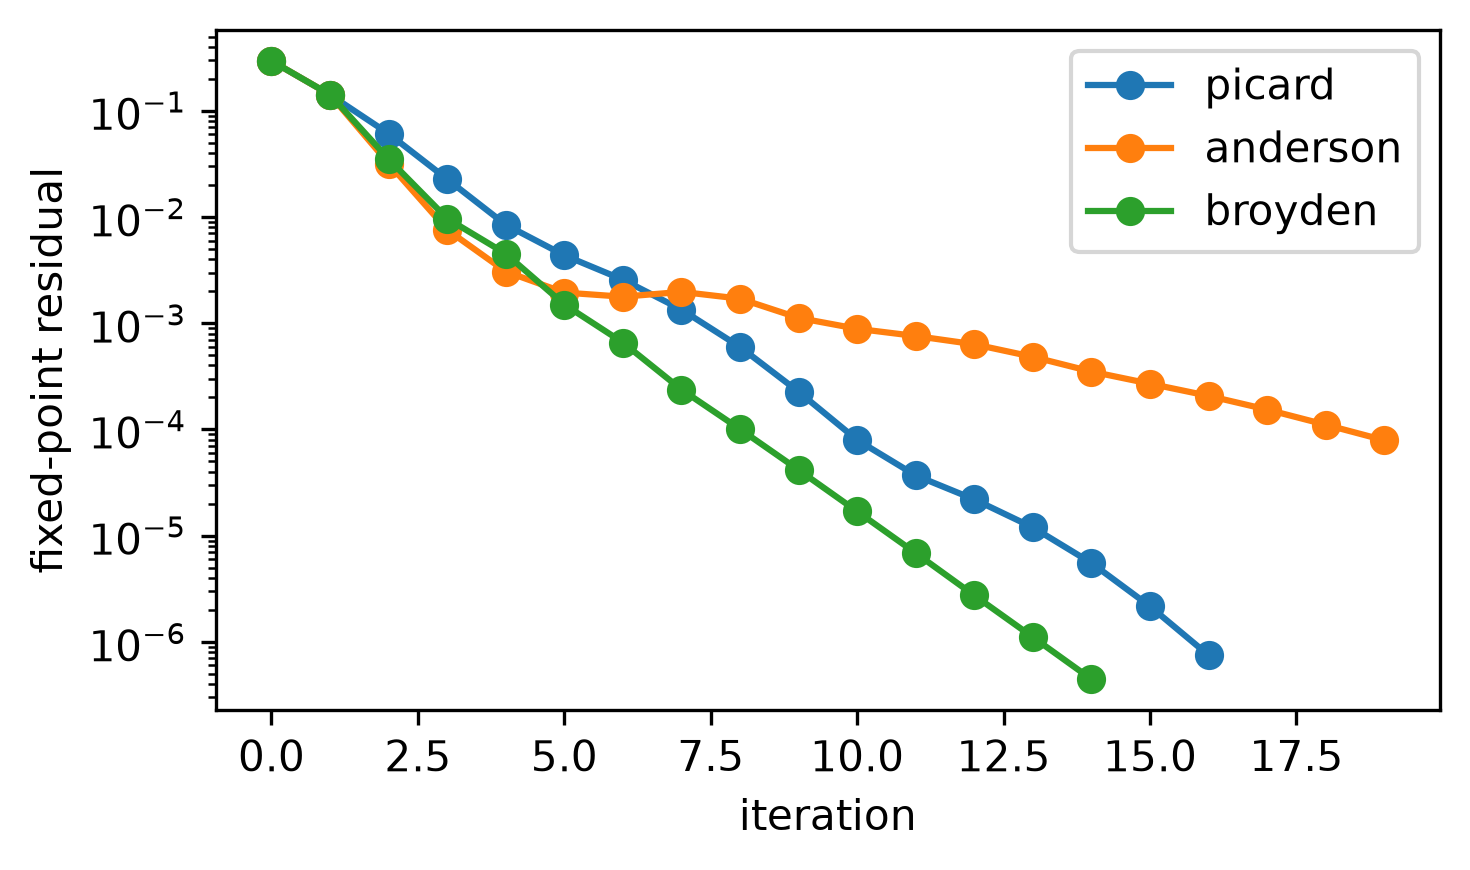

In [4]:
plt.figure(figsize=(5, 3))
for solver, result in solver_runs.items():
    plt.plot(result.residuals, marker="o", label=solver)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("fixed-point residual")
plt.legend()
plt.tight_layout()

For small states, materialize $J_z$. For larger states, use products
$J_zv$ and $J_z^\top v$.

In [5]:
result = fixed_point(f, z0, SolverConfig(solver="anderson", max_iter=20, alpha=0.6))
J = full_jacobian(f, result.z)
probe = torch.ones_like(result.z)
_, Jv = jvp(f, result.z, probe)
Jtv = vjp(f, result.z, probe)
print("J shape:", tuple(J.shape))
print("Jv:", Jv)
print("J^T v:", Jtv)

J shape: (4, 4)
Jv: tensor([-1.0958, -0.8107, -0.3577,  0.5230])
J^T v: tensor([-0.6240,  0.1531, -0.5369, -0.7335])


In [6]:
report = stability_report(f, result.z, samples=4, iters=8)
report

StabilityReport(residual=5.730579505325295e-05, spectral_radius=0.4160735309123993, jacobian_norm_estimate=0.9196919798851013, samples=4)

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762

## From 02 Solvers And Jacobians to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the latent vector or tensor z |
| Condition | the injected observation x |
| Repeated computation | the tied map f_theta(z, x) |
| Required invariants | state shape and a decreasing or bounded residual |
| Replaceable components | transition, damping, stopping rule, backward solver, and readout |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**distance to an analytic fixed point and final relative residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **latent width, solver tolerance, and iteration budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '02_solvers_and_jacobians.ipynb',
    "state": 'the latent vector or tensor z',
    "condition": 'the injected observation x',
    "transition": 'the tied map f_theta(z, x)',
    "invariants": 'state shape and a decreasing or bounded residual',
    "compact_metric": 'distance to an analytic fixed point and final relative residual',
    "scale_axis": 'latent width, solver tolerance, and iteration budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '02_solvers_and_jacobians.ipynb',
 'state': 'the latent vector or tensor z',
 'condition': 'the injected observation x',
 'transition': 'the tied map f_theta(z, x)',
 'invariants': 'state shape and a decreasing or bounded residual',
 'compact_metric': 'distance to an analytic fixed point and final relative residual',
 'scale_axis': 'latent width, solver tolerance, and iteration budget'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How is each solver update derived? | [Solver Derivation Lab](https://jseluis.github.io/silva-networks/learn/solver-derivation-lab/) |
| How do Jacobians support stability claims? | [Jacobians and Stability](https://jseluis.github.io/silva-networks/learn/jacobians/) |
| Which diagnostic functions consume these traces? | [Diagnostics API](https://jseluis.github.io/silva-networks/api/diagnostics/) |
